### Import libraries and load data

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/raw/train.csv')


### Dropped px_height zero rows & Replaced sc_w zeros with mean

In [74]:
# Drop rows where px_height is 0
df = df[df['px_height']!=0]

# Replace sc_w zeros with mean (of non-zero values only)
sc_w_mean = df[df['sc_w']!=0]['sc_w'].mean()
df['sc_w'] = df['sc_w'].replace(0,sc_w_mean)

# verify fixes
print(df.shape)
print((df['px_height']==0).sum())
print((df['sc_w']==0).sum())

(1998, 21)
0
0


### Log Transformation for px_height & sc_w

In [75]:
df['px_height'] = np.log1p(df['px_height'])
df['total_pixels']=df['px_width']*df['px_height']

df['sc_w']=np.log1p(df['sc_w'])



### Drop Near-Zero Correlation

In [82]:
#df.drop(['m_dep','n_cores','four_g','clock_speed','blue','dual_sim','fc','sc_h','three_g','wifi'],axis=1,inplace=True,errors='ignore')
df_keep =['ram','battery_power','total_pixels','price_range','int_memory','sc_w']
df = df[df_keep]
df.info()

<class 'pandas.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ram            1998 non-null   int64  
 1   battery_power  1998 non-null   int64  
 2   total_pixels   1998 non-null   float64
 3   price_range    1998 non-null   int64  
 4   int_memory     1998 non-null   int64  
 5   sc_w           1998 non-null   float64
dtypes: float64(2), int64(4)
memory usage: 109.3 KB


### Separate features and target variable

In [83]:
X = df.drop('price_range',axis=1,errors='ignore')
y = df['price_range']

print(X.shape)
print(y.shape)


(1998, 5)
(1998,)


### Train/test split (80/20, stratified)

In [84]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(1598, 5)
(400, 5)


### Feature scaling (StandardScaler)

In [85]:
# 1.create scaler
scaler = StandardScaler()

#2.fit and transform training data
X_train_scaled =scaler.fit_transform(X_train)

# 3. transform test data
X_test_scaled = scaler.transform(X_test)

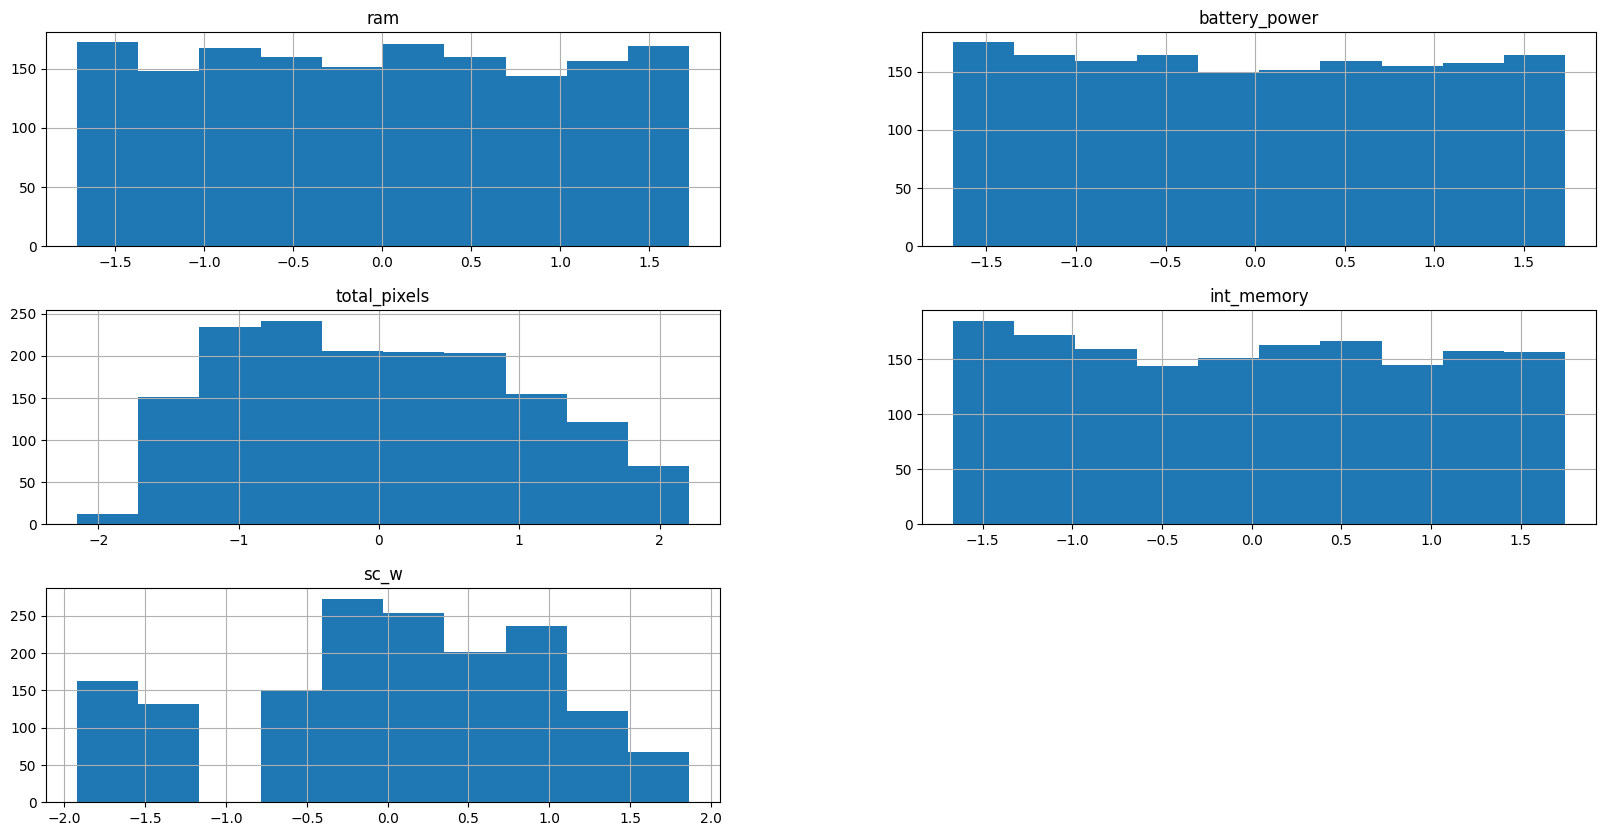

In [86]:
# 4. Convert to DataFrame to use .hist()
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# 5. Visualize
X_train_scaled_df.hist(figsize=(20, 10), bins=10)
plt.show()

### Save the processed data

In [87]:
import os
os.makedirs('../data/processed',exist_ok =True)

np.save('../data/processed/X_train_scaled.npy',X_train_scaled)
np.save('../data/processed/X_test_scaled.npy',X_test_scaled)
np.save('../data/processed/y_train.npy',y_train)
np.save('../data/processed/y_test.npy',y_test)

print("Data saved ssuccessfully.")

Data saved ssuccessfully.
